In [1]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import tensorflow as tf
import tensorflow.keras as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Flatten , MaxPooling2D , Conv2D ,SpatialDropout2D, BatchNormalization, GlobalMaxPool2D

In [3]:
# I have taken this data because the categories this data have are not in the imagenet so that is why it is scratched model I can check my capabilities

# https://www.kaggle.com/datasets/puneet6060/intel-image-classification


In [4]:
from google.colab import files
files.upload(r"C:\Users\Dev\Downloads\kaggle.json")  # select your kaggle.json here

Saving kaggle.json to C:\Users\Dev\Downloads\kaggle.json/kaggle.json


{'C:\\Users\\Dev\\Downloads\\kaggle.json/kaggle.json': b'{"username":"devsagarsoni","key":"8ecaec472475aa3e0f1318507bcf7fbb"}'}

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [6]:
!kaggle datasets download -d puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:01<00:00, 189MB/s]



In [7]:
!unzip intel-image-classification.zip -d intel_data

Streaming output truncated to the last 5000 lines.
  inflating: intel_data/seg_train/seg_train/mountain/7506.jpg  
  inflating: intel_data/seg_train/seg_train/mountain/7537.jpg  
  inflating: intel_data/seg_train/seg_train/mountain/7539.jpg  
  inflating: intel_data/seg_train/seg_train/mountain/7551.jpg  
  inflating: intel_data/seg_train/seg_train/mountain/7560.jpg  
  inflating: intel_data/seg_train/seg_train/mountain/7565.jpg  
  inflating: intel_data/seg_train/seg_train/mountain/7578.jpg  
  inflating: intel_data/seg_train/seg_train/mountain/7581.jpg  
  inflating: intel_data/seg_train/seg_train/mountain/7586.jpg  
  inflating: intel_data/seg_train/seg_train/mountain/7647.jpg  
  inflating: intel_data/seg_train/seg_train/mountain/7652.jpg  
  inflating: intel_data/seg_train/seg_train/mountain/7654.jpg  
  inflating: intel_data/seg_train/seg_train/mountain/7662.jpg  
  inflating: intel_data/seg_train/seg_train/mountain/767.jpg  
  inflating: intel_data/seg_train/seg_train/mountain/7

# DATA LOADING

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(directory = '/content/intel_data/seg_train/seg_train',
                                            labels = 'inferred',
                                            batch_size= 32,
                                            image_size = (150,150),seed= 45)

test_ds = tf.keras.utils.image_dataset_from_directory(directory = '/content/intel_data/seg_test/seg_test',
                                            labels = 'inferred',
                                            batch_size= 32,
                                            image_size = (150,150),seed= 45)


Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


# DATA NORMALISIING

In [9]:
# NORMALISING DATA
train_data = train_ds.map(lambda x, y: (x / 255, y))
test_data = test_ds.map(lambda x, y: (x / 255, y))


# SAMPLE TRAINING DATA (2 samples of each 6 categories)

In [10]:
# CLASS LABELS
{'buildings' : 0,
'forest' : 1,
'glacier' : 2,
'mountain' : 3,
'sea' : 4,
'street' : 5 }

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

In [11]:
# NOW plotting 12 images of 2 of each label in a 2x6 subplot
# At every run you will get different images because image is shuffled
import scipy.stats as st


These 12 images are randomly chosen from the training data


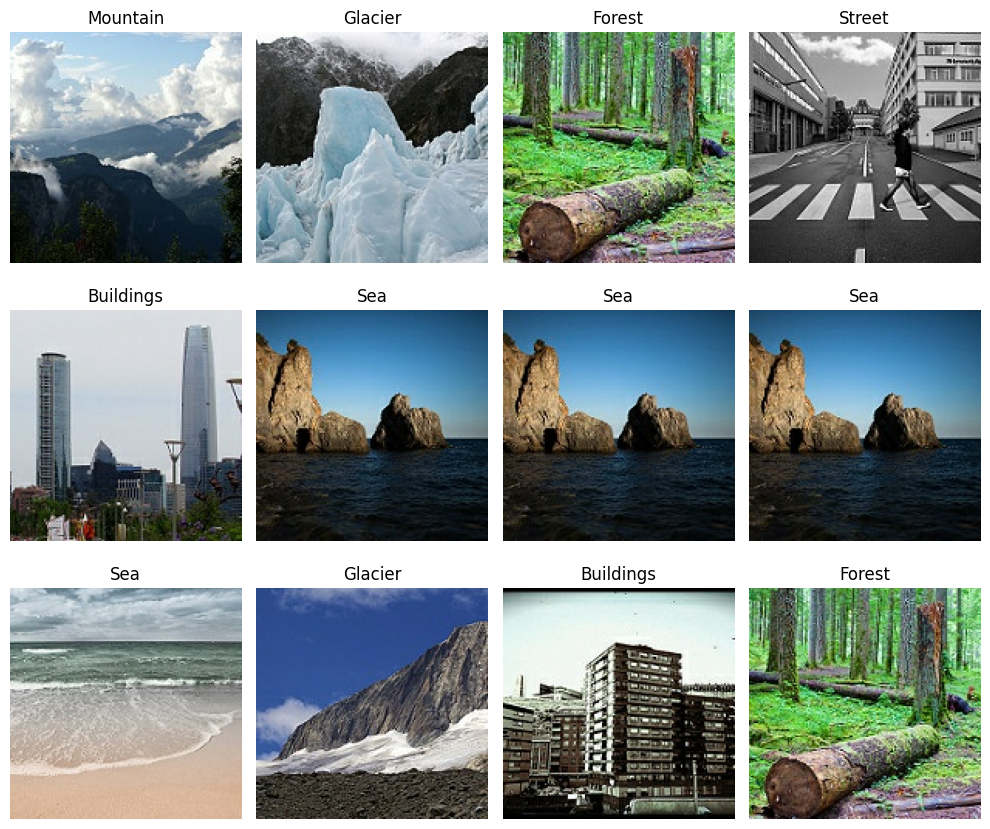

In [12]:
# THESE ARE THE MEANING OF CLASS LABELS FORM 0 TO
class_label = ['Buildings','Forest','Glacier',
                'Mountain','Sea','Street']


plt.figure(figsize = (10,10))

# PLOTTING
for i, (images,labels) in enumerate(train_data.skip(5).take(5)):        # Take batch from no 6 to 10 of train_data

  for i in range(12):
    idx_1 = np.random.randint(0,32)                               # take 1st random image from batch of 32 images
    idx_2 = np.random.randint(0,32)                               # take 2st random image from batch of 32 images

    plt.subplot(3,4,i+1)
    plt.imshow(images[idx_1].numpy())
    plt.title(class_label[labels[idx_1].numpy()])

    plt.axis('off')                                     # GRIDLINES REMMOVED
  plt.tight_layout()

# PRINT
print("These 12 images are randomly chosen from the training data")


These 4 images are randomly chosen from the test data


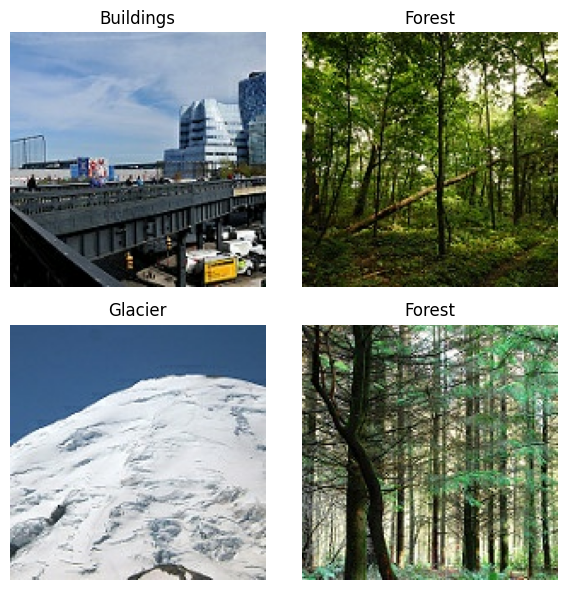

In [13]:
# SAME FOR TEST DATA ONLY 4 PLOTS

plt.figure(figsize = (6,6))

rand_batch = np.random.randint(1,len(test_data))

for i, (images,labels) in enumerate(test_data.skip(rand_batch - 1).take(1)):        # Take any batch from whole test_data ie eg- rand_batch  =10 ,skip(9).take(1)

  for i in range(4):
    idx_1 = np.random.randint(0,32)                               # take 1st random image from batch of 32 images
    idx_2 = np.random.randint(0,32)                               # take 2st random image from batch of 32 images

    plt.subplot(2,2,i+1)
    plt.imshow(images[idx_1].numpy())
    plt.title(class_label[labels[idx_1].numpy()])

    plt.axis('off')                                     # GRIDLINES REMMOVED
  plt.tight_layout()

# PRINT
print("These 4 images are randomly chosen from the test data")

# MODEL COMPARISONS

In [14]:
from tensorflow.keras.models import load_model

In [20]:
!ls -lh /content | grep XCEPTION
import os
print(os.path.exists("/content/BEST_MODEL_XCEPTION.keras"))


-rw-r--r-- 1 root root 113M Jun 10 14:50 BEST_MODEL_XCEPTION.keras
True


In [21]:
from tensorflow.keras.models import load_model

scratch_model   = load_model('/content/BEST_MODEL.keras')
mob_net_model   = load_model('/content/BEST_MODEL_MOBILENET.keras')
xception_model = load_model("/content/BEST_MODEL_XCEPTION.keras")

# CONVERTING IMAGE LABELS INTO ARRAY

In [22]:
y_test = []

for images,labels in test_data:
  y_test.extend(labels.numpy())

y_test = np.array(y_test)


# CONVERTING MODEL PREDICTIONS INTO LABELS IN ARRAY

In [23]:
# SCRATCH MODEL
y_prob1 = scratch_model.predict(test_data,verbose=0)
y_pred_scratch_model =np.array(np.argmax(y_prob1,axis=1))

# MOBILENET MODEL
y_prob2 = mob_net_model.predict(test_data,verbose=0)
y_pred_mob_net_model = np.array(np.argmax(y_prob2,axis=1))

# XCEPTION MODEL
y_prob3 = xception_model.predict(test_data,verbose=0)
y_pred_xception_model = np.array(np.argmax(y_prob3,axis=1))

In [24]:
# CLASSIFICATION REPORT
from sklearn.metrics import classification_report
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
print(classification_report(y_test,y_pred_xception_model, target_names = class_names))

## "We can't use this method because initially we have set shuffle=True, so at every run test_data is shuffled, so we have to do the prediction inside the loop"

              precision    recall  f1-score   support

   buildings       0.14      0.14      0.14       437
      forest       0.17      0.17      0.17       474
     glacier       0.19      0.18      0.19       553
    mountain       0.19      0.20      0.19       525
         sea       0.20      0.20      0.20       510
      street       0.17      0.18      0.17       501

    accuracy                           0.18      3000
   macro avg       0.18      0.18      0.18      3000
weighted avg       0.18      0.18      0.18      3000



# THE PREVIOSU METHOD CANT BE USED DUE TO shuffle = True

In [25]:
y_test = []
y_pred_scratch_model = []
y_pred_mob_net_model = []
y_pred_xception_model = []

for images,labels in test_data:

  y_test.extend(labels.numpy())

 # SCRATCH MODEL
  y_prob1 = scratch_model.predict(images,verbose=0)
  y_pred_scratch_model.extend((np.argmax(y_prob1,axis=1)))

  # MOBILENET MODEL
  y_prob2 = mob_net_model.predict(images,verbose=0)
  y_pred_mob_net_model.extend(np.argmax(y_prob2,axis=1))

  # XCEPTION MODEL
  y_prob3 = xception_model.predict(images,verbose=0)
  y_pred_xception_model.extend(np.argmax(y_prob3,axis=1))


y_test = np.array(y_test)
y_pred_scratch_model = np.array(y_pred_scratch_model)
y_pred_mob_net_model = np.array(y_pred_mob_net_model)
y_pred_xception_model = np.array(y_pred_xception_model)

In [26]:
Models_pred =pd.DataFrame({'True_label' : y_test,
                            'Scratch_CNN_pred': y_pred_scratch_model,
                            'Mob_pred': y_pred_mob_net_model,
                            'Xception_pred': y_pred_xception_model})

Models_pred['True_label_name'] = Models_pred['True_label'].map({0 : "buildings",
                                                                1 :'forest' ,
                                                                2 :'glacier',
                                                                3 :'mountain',
                                                                4 :'sea',
                                                                5 :'street' })

Models_pred = Models_pred [ ['True_label',"True_label_name" ,"Scratch_CNN_pred"	,"Mob_pred"	,"Xception_pred"]]
Models_pred.head(10)

,True_label,True_label_name,Scratch_CNN_pred,Mob_pred,Xception_pred
0,2,glacier,2,3,3
1,4,sea,4,4,4
2,4,sea,4,4,4
3,3,mountain,3,3,3
4,5,street,5,5,5
5,3,mountain,4,2,3
6,0,buildings,0,0,0
7,5,street,5,5,5
8,0,buildings,0,0,0
9,4,sea,0,4,4


In [27]:
# CLASSIFICATION REPORT
from sklearn.metrics import classification_report
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

cf_scratch_model = classification_report(y_test , y_pred_scratch_model , target_names=class_names)
cf_mobnet_model = classification_report(y_test , y_pred_mob_net_model , target_names=class_names)
cf_xception_model = classification_report(y_test , y_pred_xception_model , target_names=class_names)

In [28]:
print("____________________________________________________________")
print("---------Classification Report for Scratch Model------------")
print("____________________________________________________________",'\n')
print(cf_scratch_model)

____________________________________________________________
---------Classification Report for Scratch Model------------
____________________________________________________________ 

              precision    recall  f1-score   support

   buildings       0.60      0.84      0.70       437
      forest       0.93      0.95      0.94       474
     glacier       0.89      0.67      0.76       553
    mountain       0.80      0.68      0.74       525
         sea       0.73      0.83      0.78       510
      street       0.79      0.74      0.76       501

    accuracy                           0.78      3000
   macro avg       0.79      0.78      0.78      3000
weighted avg       0.79      0.78      0.78      3000



In [29]:
print("____________________________________________________________")
print("---------Classification Report for MobNet Model------------")
print("____________________________________________________________",'\n')
print(cf_mobnet_model)

____________________________________________________________
---------Classification Report for MobNet Model------------
____________________________________________________________ 

              precision    recall  f1-score   support

   buildings       0.86      0.95      0.91       437
      forest       0.99      0.99      0.99       474
     glacier       0.83      0.87      0.85       553
    mountain       0.88      0.82      0.85       525
         sea       0.94      0.93      0.94       510
      street       0.95      0.89      0.92       501

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



In [30]:
print("_______________________________________________________________")
print("---------Classification Report for Xception Model ------------")
print("_______________________________________________________________",'\n')
print(cf_xception_model)

_______________________________________________________________
---------Classification Report for Xception Model ------------
_______________________________________________________________ 

              precision    recall  f1-score   support

   buildings       0.91      0.92      0.91       437
      forest       0.99      0.99      0.99       474
     glacier       0.90      0.83      0.87       553
    mountain       0.85      0.89      0.87       525
         sea       0.95      0.95      0.95       510
      street       0.92      0.94      0.93       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



# CONFUSION MATRICES

In [31]:
# CLASSIFICATION REPORT
from sklearn.metrics import confusion_matrix
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

cm_scratch_model = confusion_matrix(y_test , y_pred_scratch_model)
cm_mobnet_model = confusion_matrix(y_test , y_pred_mob_net_model )
cm_xception_model = confusion_matrix(y_test , y_pred_xception_model)

______________________________________________________________________
---------heatmap of confusion matrix for Scratch CNN Model------------
______________________________________________________________________ 



<Axes: title={'center': 'heatmap of confusion matrix for Scratch CNN Model'}>

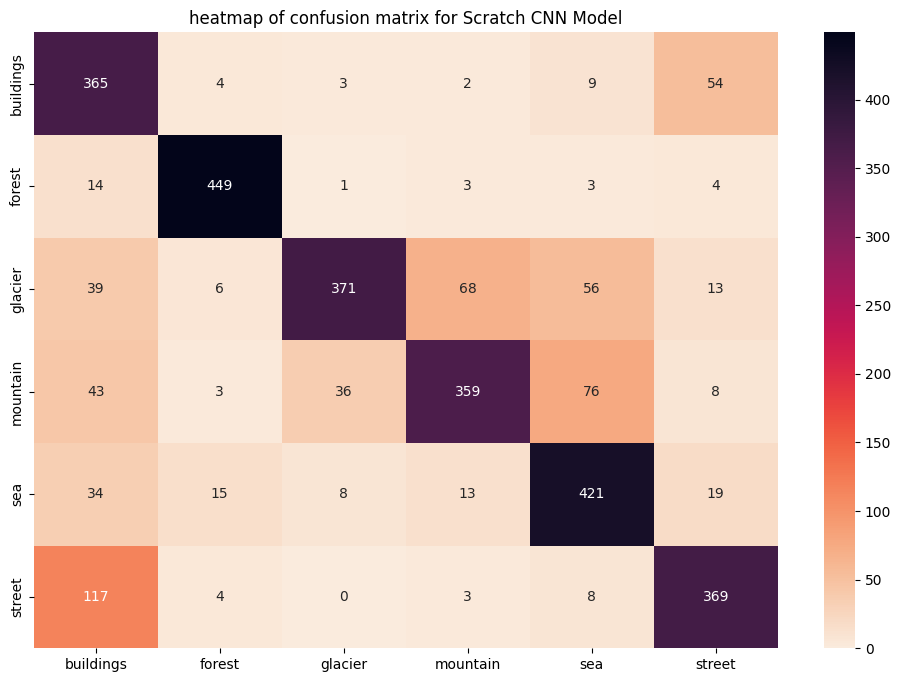

In [76]:
print("______________________________________________________________________")
print("---------heatmap of confusion matrix for Scratch CNN Model------------")
print("______________________________________________________________________",'\n')


plt.figure(figsize=(12,8))
plt.title("heatmap of confusion matrix for Scratch CNN Model")
sns.heatmap(cm_scratch_model,
            xticklabels= class_names,
            yticklabels= class_names,
            annot=True,
            fmt='.4g',
            cmap='rocket_r'
            )

______________________________________________________________________
---------heatmap of confusion matrix for Mobnet CNN Model ------------
______________________________________________________________________ 



<Axes: title={'center': 'heatmap of confusion matrix for Mobnet CNN Model'}>

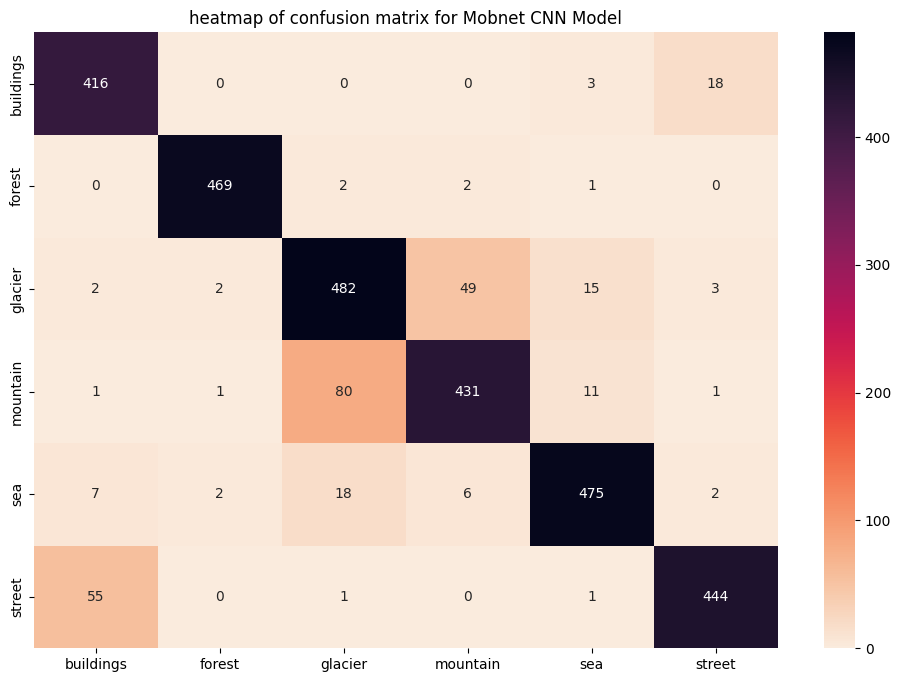

In [75]:
print("______________________________________________________________________")
print("---------heatmap of confusion matrix for Mobnet CNN Model ------------")
print("______________________________________________________________________",'\n')

plt.figure(figsize=(12,8))
plt.title("heatmap of confusion matrix for Mobnet CNN Model")
sns.heatmap(cm_mobnet_model,
            xticklabels= class_names,
            yticklabels= class_names,
            annot=True,
            fmt='.4g',
            cmap='rocket_r'
            )

______________________________________________________________________
---------heatmap of confusion matrix for xception CNN Model ------------
______________________________________________________________________ 



<Axes: title={'center': 'heatmap of confusion matrix for xception CNN Model'}>

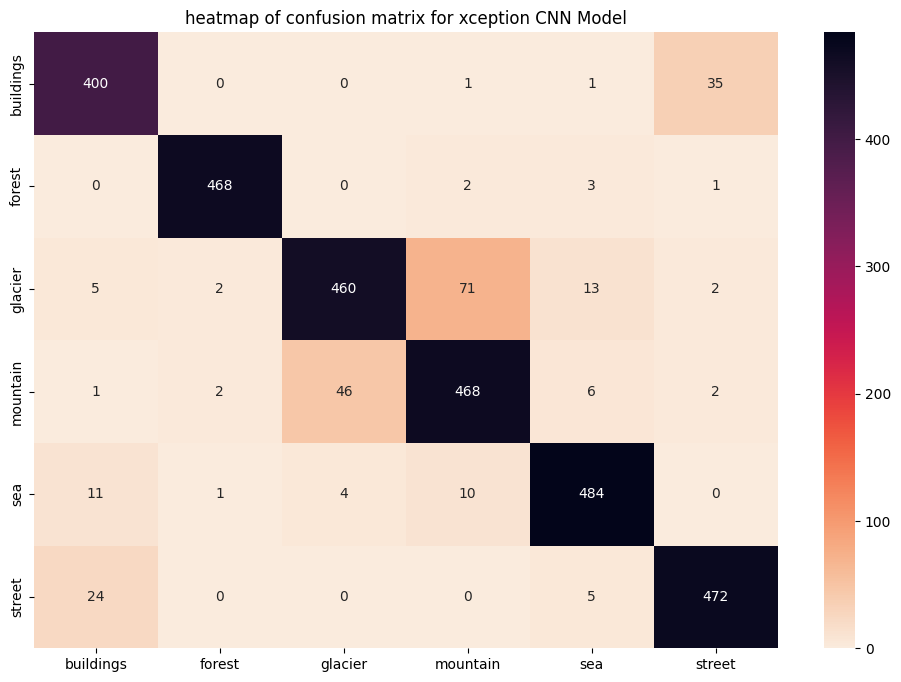

In [74]:
print("______________________________________________________________________")
print("---------heatmap of confusion matrix for xception CNN Model ------------")
print("______________________________________________________________________",'\n')

plt.figure(figsize=(12,8))
plt.title("heatmap of confusion matrix for xception CNN Model")
sns.heatmap(cm_xception_model,
            xticklabels= class_names,
            yticklabels= class_names,
            annot=True,
            fmt='.4g',
            cmap='rocket_r'
            )

# Bar plot of model accuracies


In [35]:
from sklearn.metrics import accuracy_score

scratch_cnn_acc =  accuracy_score(y_test,y_pred_scratch_model)
mobnet_acc =  accuracy_score(y_test,y_pred_mob_net_model)
xcep_acc =  accuracy_score(y_test,y_pred_xception_model)

In [36]:
accuracies = pd.DataFrame({'Model':['Scratch CNN','MobileNet','Xception'],
                          'Test_accuracy':[scratch_cnn_acc,mobnet_acc,xcep_acc]})

Text(0.5, 1.0, 'Test Accuracies')

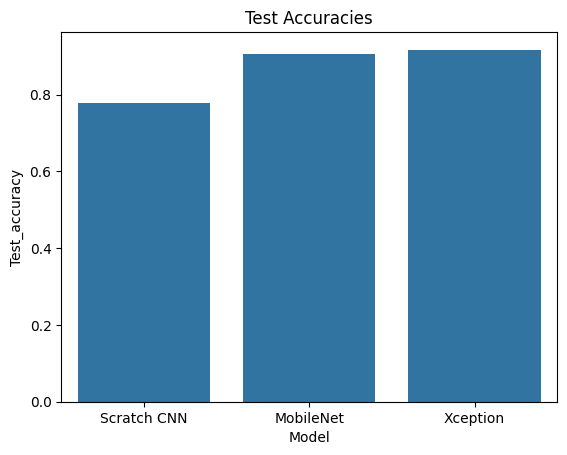

In [37]:
sns.barplot(data=accuracies, x= 'Model',y  ='Test_accuracy',)
plt.title("Test Accuracies")

# Scenes for the prediction data we have 7200 plus images but with no labels So what am I doing I will predict for all images and compare the predictions of each model without label

In [99]:
pred_ds = tf.keras.utils.image_dataset_from_directory(directory = "/content/intel_data/seg_pred",
                                            labels = 'inferred',
                                            batch_size= 32,
                                            image_size = (150,150)
                                            ,seed= 45,
                                            shuffle = False  )



Found 7301 files belonging to 1 classes.


In [100]:
pred_data = pred_ds.map(lambda x,y : (x/255.,y))

In [101]:
import numpy as np

y_pred1_scratch_model = []
y_pred1_mob_net_model = []
y_pred1_xception_model = []

for images, labels in pred_data:

    # SCRATCH MODEL
    y_prob11 = scratch_model.predict(images, verbose=0)
    y_pred1_scratch_model.extend(np.argmax(y_prob11, axis=1))

    # MOBILENET MODEL
    y_prob21 = mob_net_model.predict(images, verbose=0)
    y_pred1_mob_net_model.extend(np.argmax(y_prob21, axis=1))

    # XCEPTION MODEL
    y_prob31 = xception_model.predict(images, verbose=0)
    y_pred1_xception_model.extend(np.argmax(y_prob31, axis=1))

# convert to numpy arrays
y_pred1_scratch_model = np.array(y_pred1_scratch_model)
y_pred1_mob_net_model = np.array(y_pred1_mob_net_model)
y_pred1_xception_model = np.array(y_pred1_xception_model)


In [102]:
Models_pred =pd.DataFrame({'Image_no' : range(1,7302),
                            'Scratch_CNN_pred': y_pred1_scratch_model,
                            'Mob_pred': y_pred1_mob_net_model,
                            'Xception_pred': y_pred1_xception_model})

({0 : "buildings",
  1 :'forest' ,
  2 :'glacier',
  3 :'mountain',
  4 :'sea',
  5 :'street' })

Models_pred.head(10)


,Image_no,Scratch_CNN_pred,Mob_pred,Xception_pred
0,1,0,0,0
1,2,3,3,3
2,3,5,5,5
3,4,2,3,3
4,5,0,3,3
5,6,1,1,1
6,7,4,4,4
7,8,2,2,2
8,9,4,4,4
9,10,5,5,5


In [103]:
import scipy.stats as st
Models_pred['Mode_pred'] =  st.mode(Models_pred[['Scratch_CNN_pred'	,'Mob_pred'	,'Xception_pred']],axis=1)[0]
Models_pred['Mode_val_freq'] =  st.mode(Models_pred[['Scratch_CNN_pred'	,'Mob_pred'	,'Xception_pred']],axis=1)[1]

,Image_no,Scratch_CNN_pred,Mob_pred,Xception_pred,Mode_pred,Mode_val_freq
0,1,0,0,0,0,3
1,2,3,3,3,3,3
2,3,5,5,5,5,3
3,4,2,3,3,3,2
4,5,0,3,3,3,2
5,6,1,1,1,1,3
6,7,4,4,4,4,3
7,8,2,2,2,2,3
8,9,4,4,4,4,3
9,10,5,5,5,5,3


In [105]:
print(f"""Out of 7200+ unlabelled images
all the three models give same prediction for {len(Models_pred[Models_pred['Mode_val_freq']==3])} images
and out of two of them give same prediction for {len(Models_pred[Models_pred['Mode_val_freq']==2])} images
and all gives different predictions for {len(Models_pred[Models_pred['Mode_val_freq']==1])} images""")

Out of 7200+ unlabelled images
all the three models give same prediction for 5477 images
and out of two of them give same prediction for 1681 images
and all gives different predictions for 143 images


Text(0.5, 1.0, 'Frequency of classes')

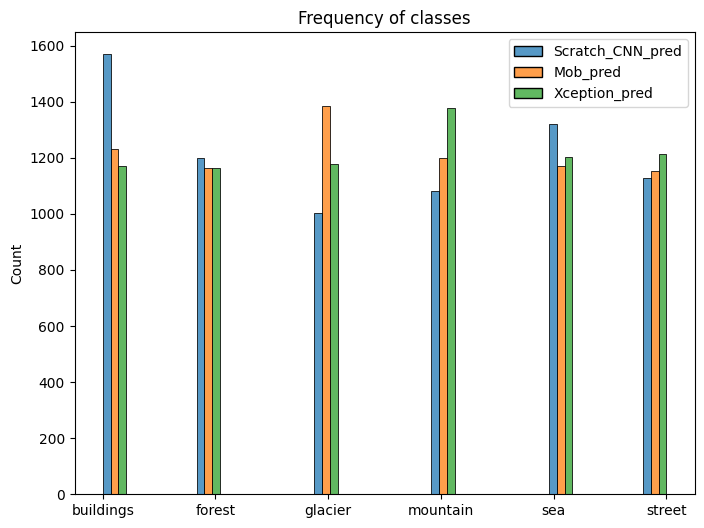

In [184]:
plt.figure(figsize=(8,6))
sns.histplot(Models_pred.iloc[:,[1,2,3]],color="#2ca02c",multiple="dodge")
plt.xticks(ticks=[0, 1, 2, 3, 4, 5], labels=class_names)
plt.title("Frequency of classes")


# Visualizing the disagreement images
- Out of all totally disagreement images taking a sample of 12
- Then visualizing them and
- Creating a data frame with true label by observing and the predicted label with the probability


In [109]:
Models_pred[Models_pred['Mode_val_freq']==1]
diagg_img_list = Models_pred[Models_pred['Mode_val_freq']==1].values
# Randomly selecting 12 images from this so that we can visualize
diagg_img = Models_pred[Models_pred['Mode_val_freq']==1]['Image_no'].sample(12,random_state=45)

#Index
diagg_img_idx = diagg_img.values

In [124]:
img_list = []
batch_size =32

for batch_idx, (images, labels) in enumerate(pred_data):
    for j in range(len(images)):
        global_index = batch_idx * batch_size + j
        if global_index in diagg_img_idx:
            img_list.append(images[j].numpy())


In [172]:
disag_df = Models_pred[Models_pred['Mode_val_freq']==1].sample(12,random_state=45).reset_index(drop=True)
for i in range(12):
  disag_df.loc[i,'Pred_class']  = "Scratch_CNN_pred- "+ str(class_names[disag_df.iloc[i,1]]) + ", MobileNet_pred- "+ str(class_names[disag_df.iloc[i,2]]) + ", Xception_pred- " + str(class_names[disag_df.iloc[i,3]] )

In [173]:
disag_df

,Image_no,Scratch_CNN_pred,Mob_pred,Xception_pred,Mode_pred,Mode_val_freq,Pred_class
0,89,3,4,2,2,1,"Scratch_CNN_pred- mountain, MobileNet_pred- se..."
1,1359,4,2,3,2,1,"Scratch_CNN_pred- sea, MobileNet_pred- glacier..."
2,2172,4,2,3,2,1,"Scratch_CNN_pred- sea, MobileNet_pred- glacier..."
3,4010,0,2,3,0,1,"Scratch_CNN_pred- buildings, MobileNet_pred- g..."
4,3805,3,2,4,2,1,"Scratch_CNN_pred- mountain, MobileNet_pred- gl..."
5,3879,4,2,3,2,1,"Scratch_CNN_pred- sea, MobileNet_pred- glacier..."
6,5058,5,2,3,2,1,"Scratch_CNN_pred- street, MobileNet_pred- glac..."
7,315,5,2,4,2,1,"Scratch_CNN_pred- street, MobileNet_pred- glac..."
8,3930,0,3,4,0,1,"Scratch_CNN_pred- buildings, MobileNet_pred- m..."
9,2223,0,2,3,0,1,"Scratch_CNN_pred- buildings, MobileNet_pred- g..."


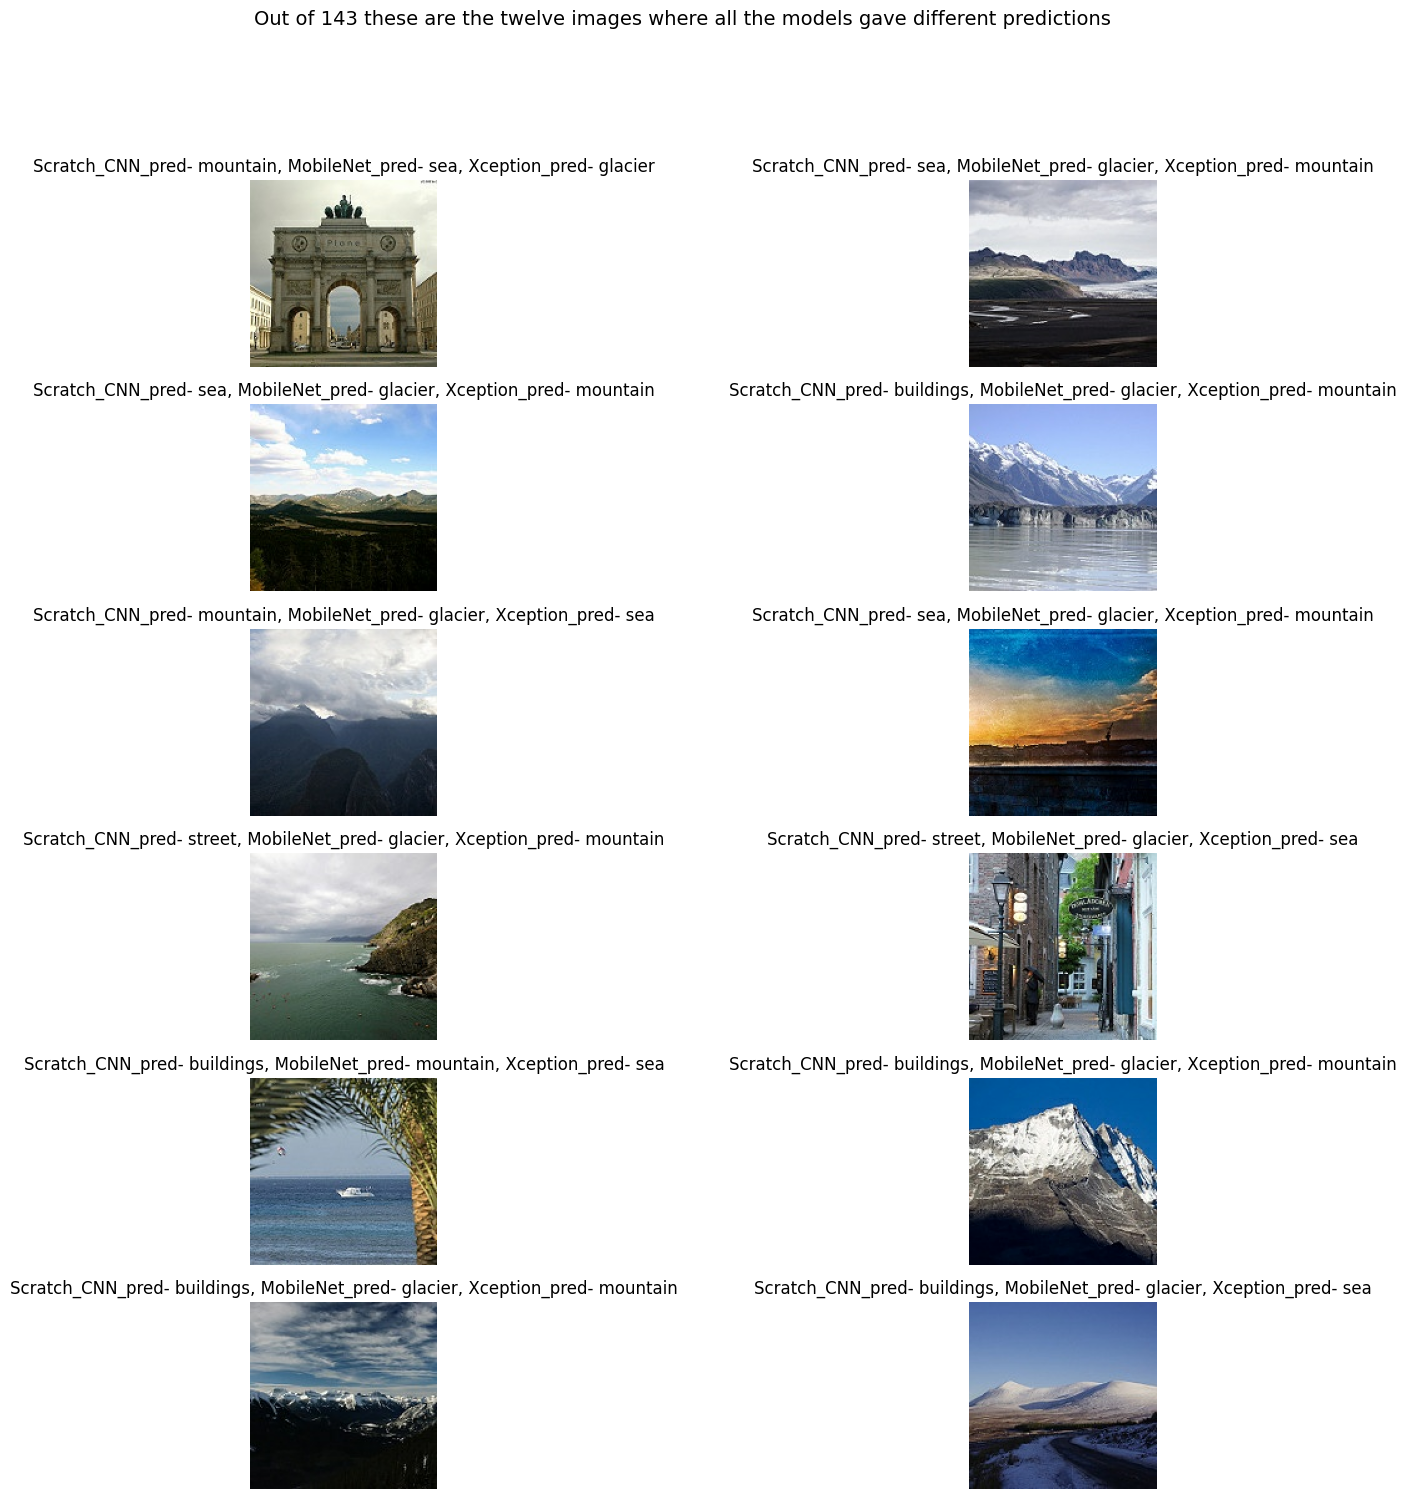

<Figure size 640x480 with 0 Axes>

In [179]:
plt.figure(figsize=(17, 17))

plt.suptitle("Out of 143 these are the twelve images where all the models gave different predictions", fontsize=14)

for i in range(12):
    plt.subplot(6,2, i + 1)
    plt.title(disag_df.loc[i,'Pred_class'])
    plt.imshow(img_list[i])
    plt.axis("off")

plt.show()

plt.savefig("Diaggrement images")

In [210]:
observed_lab = ['Building','Glacier','Mountain','Glacier',
            'Mountain','Sea','Sea','Street',
            'Sea','Glacier','Glacier','Glacier',]

In [209]:
import numpy as np
pred_scratch = []
pred_mob = []
pred_xcep = []


for i in range(12):

  # expanding dim
  img = np.expand_dims(img_list[i], axis=0)   # shape becomes (1, 150, 150, 3)

  # Prediction

  pred_scratch.append(scratch_model.predict(img).max())
  pred_mob.append(mob_net_model.predict(img).max())
  pred_xcep.append(xception_model.predict(img).max())


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━

In [223]:
# This data frame will show the obtained probabilities of disagreement images
df_prob = pd.DataFrame()
df_prob['True_label_by_observing'] = observed_lab

for i in range(12):

  df_prob.loc[i,'Scratch_CNN_pred'] = class_names[pd.to_numeric(disag_df.loc[i,'Scratch_CNN_pred'])]
  df_prob['Scratch_CNN_pred_prob'] = pred_scratch

  df_prob.loc[i,'MobileNet_pred'] = class_names[pd.to_numeric(disag_df.loc[i,"Mob_pred"])]
  df_prob['MobileNet_pred_prob'] = pred_mob

  df_prob.loc[i,'Xception_pred'] = class_names[pd.to_numeric(disag_df.loc[i,'Xception_pred'])]
  df_prob['Xception_pred_prob'] = pred_xcep

In [222]:
df_prob

,True_label_by_observing,Scratch_CNN_pred,Scratch_CNN_pred_prob,MobileNet_pred,MobileNet_pred_prob,Xception_pred,Xception_pred_prob
0,Building,mountain,0.889837,sea,1.000000,glacier,0.999274
1,Glacier,sea,0.657179,glacier,0.970971,mountain,0.503602
2,Mountain,sea,0.429148,glacier,0.998528,mountain,0.971821
3,Glacier,buildings,0.352941,glacier,0.999877,mountain,0.556520
4,Mountain,mountain,0.979716,glacier,0.996190,sea,0.946855
5,Sea,sea,0.926548,glacier,0.841423,mountain,0.948722
6,Sea,street,0.964477,glacier,0.999988,mountain,0.997339
7,Street,street,0.933025,glacier,0.679480,sea,0.971033
8,Sea,buildings,0.748948,mountain,0.961097,sea,0.958525
9,Glacier,buildings,0.733452,glacier,0.661211,mountain,0.977979
